# 00 — Data Overview

Sanity-check the unified corpus built by `scripts/parse_sources.py`.
Expected: five sources, unique `doc_id`s, reasonable text length distribution,
no HTML/markdown artefacts leaking through tokenisation.


In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'experiments' else Path.cwd()
PARQUET = ROOT / 'data' / 'raw' / 'documents.parquet'

df = pd.read_parquet(PARQUET)
df['text_len'] = df['text'].str.len()
df['metadata'] = df['metadata'].apply(json.loads)
print(f'loaded {len(df)} documents from {PARQUET}')
df.head(3)

loaded 2495 documents from /home/hehek/kurs/garag/data/raw/documents.parquet


,doc_id,source,url,title,text,metadata,text_len
0,mitre_attack:M1031,mitre_attack,https://attack.mitre.org/mitigations/M1031/,Network Intrusion Prevention,Use intrusion detection signatures to block tr...,"{'stix_type': 'course-of-action', 'version': '...",74
1,mitre_attack:M1016,mitre_attack,https://attack.mitre.org/mitigations/M1016/,Vulnerability Scanning,Vulnerability scanning involves the automated ...,"{'stix_type': 'course-of-action', 'version': '...",2692
2,mitre_attack:M1035,mitre_attack,https://attack.mitre.org/mitigations/M1035/,Limit Access to Resource Over Network,"Restrict access to network resources, such as ...","{'stix_type': 'course-of-action', 'version': '...",2343


## 1. Counts per source


source
mitre_attack    1705
hackerone        500
mitre_atlas      275
owasp             10
man_pages          5


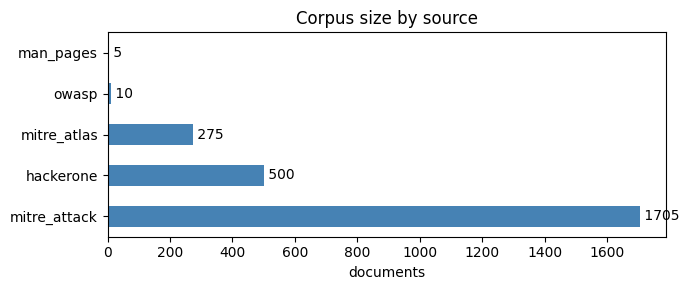

In [2]:
counts = df.groupby('source').size().sort_values(ascending=False)
print(counts.to_string())
assert counts.sum() == len(df)

fig, ax = plt.subplots(figsize=(7, 3))
counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('documents')
ax.set_ylabel('')
ax.set_title('Corpus size by source')
for i, v in enumerate(counts.values):
    ax.text(v, i, f' {v}', va='center')
plt.tight_layout()
plt.show()

## 2. Text length distribution


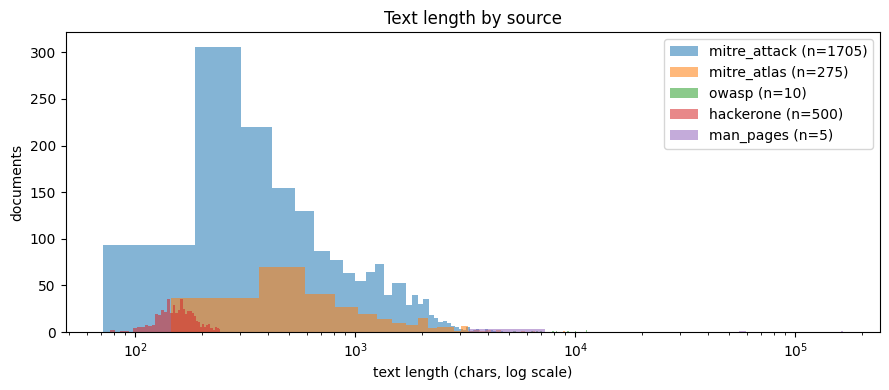

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
hackerone,500.0,161.0,31.0,77.0,140.0,159.0,179.0,243.0
man_pages,5.0,46584.0,69702.0,3267.0,3665.0,5087.0,56436.0,164465.0
mitre_atlas,275.0,1129.0,1083.0,145.0,470.0,725.0,1396.0,9004.0
mitre_attack,1705.0,873.0,719.0,71.0,315.0,604.0,1271.0,4700.0
owasp,10.0,8330.0,2115.0,5219.0,6754.0,8058.0,9900.0,11327.0


In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for src in df['source'].unique():
    sub = df[df['source'] == src]['text_len']
    ax.hist(sub, bins=40, alpha=0.55, label=f'{src} (n={len(sub)})')
ax.set_xscale('log')
ax.set_xlabel('text length (chars, log scale)')
ax.set_ylabel('documents')
ax.set_title('Text length by source')
ax.legend()
plt.tight_layout()
plt.show()

df.groupby('source')['text_len'].describe().round(0)

## 3. Top-20 tokens per source

A whitespace split — this is intentionally crude. We're looking for HTML tags, markdown
artefacts, or debugging noise that would pollute the downstream BM25 index.


In [4]:
import re

def top_tokens(text_series, n=20):
    joined = ' '.join(text_series.astype(str).str.lower().tolist())
    tokens = re.findall(r"[a-z][a-z0-9_\-]{2,}", joined)
    return Counter(tokens).most_common(n)

for src in sorted(df['source'].unique()):
    top = top_tokens(df[df['source'] == src]['text'])
    print(f'\n── {src} ({len(df[df["source"] == src])} docs)')
    for tok, cnt in top:
        print(f'  {tok:20s} {cnt}')


── hackerone (500 docs)
  hackerone            593
  report               507
  title                501
  disclosed            500
  upvotes              500
  bounty               238
  xss                  143
  com                  115
  injection            114
  generic              94
  via                  85
  improper             84
  cross-site           82
  access               77
  scripting            75
  and                  66
  information          63
  stored               62
  request              56
  sql                  56

── man_pages (5 docs)
  the                  1341
  and                  602
  nmap                 538
  https                441
  for                  378
  com                  378
  scan                 332
  are                  281
  this                 279
  that                 247
  with                 230
  you                  227
  port                 217
  github               204
  href                 177
  img            

## 4. Sanity checks


In [5]:
assert df['doc_id'].is_unique, 'doc_id not unique'
assert df['text_len'].min() >= 10, f"min text length: {df['text_len'].min()}"
assert set(df['source']) == {
    'mitre_attack', 'mitre_atlas', 'owasp', 'hackerone', 'man_pages'
}, f"sources: {set(df['source'])}"

url_coverage = df['url'].notna().sum() / len(df)
print(f'url coverage: {url_coverage:.1%}')
assert url_coverage >= 0.95

empty_titles = (df['title'].fillna('').str.len() == 0).sum()
print(f'empty titles: {empty_titles}')
assert empty_titles == 0

print('all sanity checks passed')

url coverage: 100.0%
empty titles: 0
all sanity checks passed


## 5. Sample documents (3 per source)


In [6]:
import random

rng = random.Random(42)
for src in sorted(df['source'].unique()):
    sub = df[df['source'] == src]
    sample = sub.sample(min(3, len(sub)), random_state=42)
    print(f'\n===== {src} =====')
    for _, row in sample.iterrows():
        preview = row['text'][:400].replace('\n', ' ')
        print(f"\n{row['doc_id']}  ({row['text_len']} chars)")
        print(f"  title: {row['title'][:100]}")
        print(f"  url:   {row['url']}")
        print(f"  text:  {preview}...")
        print(f"  meta:  {row['metadata']}")


===== hackerone =====

hackerone:2051931  (134 chars)
  title: Blind SQL injection on id.indrive.com
  url:   https://hackerone.com/reports/2051931
  text:  Blind SQL Injection in inDrive. Report title: Blind SQL injection on id.indrive.com Disclosed on HackerOne, 193 upvotes, $4134 bounty....
  meta:  {'program': 'inDrive', 'vuln_type': 'Blind SQL Injection', 'upvotes': 193, 'bounty_usd': 4134.0}

hackerone:968082  (185 chars)
  title: Cross-Site-Scripting on www.tiktok.com and m.tiktok.com leading to Data Exfiltration
  url:   https://hackerone.com/reports/968082
  text:  Cross-site Scripting (XSS) - Reflected in TikTok. Report title: Cross-Site-Scripting on www.tiktok.com and m.tiktok.com leading to Data Exfiltration Disclosed on HackerOne, 466 upvotes....
  meta:  {'program': 'TikTok', 'vuln_type': 'Cross-site Scripting (XSS) - Reflected', 'upvotes': 466, 'bounty_usd': 0.0}

hackerone:1543159  (189 chars)
  title: Able to approve admin approval and change effective status without 

## 6. Per-source text length summary (final table)


In [7]:
summary = df.groupby('source').agg(
    docs=('doc_id', 'count'),
    text_min=('text_len', 'min'),
    text_mean=('text_len', lambda s: int(s.mean())),
    text_median=('text_len', lambda s: int(s.median())),
    text_max=('text_len', 'max'),
    urls=('url', lambda s: s.notna().sum()),
)
summary.loc['TOTAL'] = [
    len(df),
    df['text_len'].min(),
    int(df['text_len'].mean()),
    int(df['text_len'].median()),
    df['text_len'].max(),
    df['url'].notna().sum(),
]
summary

,docs,text_min,text_mean,text_median,text_max,urls
source,,,,,,
hackerone,500,77,160,159,243,500
man_pages,5,3267,46584,5087,164465,5
mitre_atlas,275,145,1129,725,9004,275
mitre_attack,1705,71,872,604,4700,1705
owasp,10,5219,8329,8058,11327,10
TOTAL,2495,71,879,462,164465,2495
